<a href="https://colab.research.google.com/github/dmecoyfin/dmeyf2026/blob/ensembles_2026/ensembles/z420_ArbolesAzarosos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 4. Ensembles de Arboles de Decision

Un arbol de decisión es un modelo débil, el aumento del poder predictivo proviene al ensamblar varios arboles de decisión.
<br> Si promedio n arboles identicos, el resultados es exactamente el mismo que utilizar un solo arbol, necesito PERTURBAR cada arbol para disponer de variablidad

la variabilidad provendrá de estas fuentes:


*   Perturbar el dataset
*   Perturbar el algoritmo del arbol
*   Perturbar el dataset y el algoritmo del arbol al mismo tiempo

Se verán estos tres algoritmos


*   Arboles Azarosos
*   Random Forest
*   Gradient Boosting of Decision Trees

# URLS

In [33]:
# install.packages("here")  # solo la primera vez
library(here)

root <- here()
# dataset <- fread(file.path(path_base, "competencia_01_crudo.csv"))

In [16]:
list.files(root)

[1] "arboles"          "CazaTalentos"     "DATA"             "ensembles"       
[5] "git-zero-to-hero" "mis_pruebas"      "monday"           "zero2hero"

In [34]:
dataset_folder <- file.path(root, "DATA", "DATASETS")
exp_folder <- file.path(root, "DATA", "EXP")

dataset_url <- file.path(dataset_folder,"competencia_01_crudo.csv")

## Generacion de la clase_ternaria

Esta parte se debe correr con el runtime en lenguaje **R** Ir al menu, Runtime -> Change Runtime Tipe -> Runtime type -> R

In [22]:
require( "data.table" )

# leo el dataset
# dataset <- fread("/content/datasets/competencia_01_crudo.csv" )
dataset <- fread(dataset_url)

# calculo el periodo0 consecutivo
dsimple <- dataset[, list(
    "pos" = .I,
    numero_de_cliente,
    periodo0 = as.integer(foto_mes/100)*12 +  foto_mes%%100 ) ]


# ordeno
setorder( dsimple, numero_de_cliente, periodo0 )

# calculo topes
periodo_ultimo <- dsimple[, max(periodo0) ]
periodo_anteultimo <- periodo_ultimo - 1


# calculo los leads de orden 1 y 2
dsimple[, c("periodo1", "periodo2") :=
    shift(periodo0, n=1:2, fill=NA, type="lead"),  numero_de_cliente ]

# assign most common class values = "CONTINUA"
dsimple[ periodo0 < periodo_anteultimo, clase_ternaria := "CONTINUA" ]

# calculo BAJA+1
dsimple[ periodo0 < periodo_ultimo &
    ( is.na(periodo1) | periodo0 + 1 < periodo1 ),
    clase_ternaria := "BAJA+1" ]

# calculo BAJA+2
dsimple[ periodo0 < periodo_anteultimo & (periodo0+1 == periodo1 )
    & ( is.na(periodo2) | periodo0 + 2 < periodo2 ),
    clase_ternaria := "BAJA+2" ]


# pego el resultado en el dataset original y grabo
setorder( dsimple, pos )
dataset[, clase_ternaria := dsimple$clase_ternaria ]

fwrite( dataset,
    # file =  "/content/datasets/competencia_01.csv.gz",
    file = file.path(dataset_folder,"competencia_01.csv.gz"),
    sep = ","
)

In [23]:
setorder( dataset, foto_mes, clase_ternaria, numero_de_cliente)
dataset[, .N, list(foto_mes, clase_ternaria)]

foto_mes,clase_ternaria,N
<int>,<chr>,<int>
202103,BAJA+1,1019
202103,BAJA+2,960
202103,CONTINUA,160921
202104,BAJA+1,964
202104,BAJA+2,1139
202104,CONTINUA,161181
202105,BAJA+1,1143
202105,BAJA+2,870
202105,CONTINUA,161755


## 4.02 Arboles Azarosos

Arboles Azarosos es el nombre de un humilde algoritmo trivial (por favor NO confundir con Random Forest)
<br>Qué tipo de perturbaciones se realizan en Arboles Azarosos
* Se perturba el dataset
* No se perturba el algoritmo, es siempre rpart original

Cada  arbolito de  Arboles Azarosos se entrena sobre un dataset perturbado,  que tiene exactamente la misma cantidad de registros pero solo un subconjunto de los atributos (campos)  del dataset, tomados al azar, de los originales.
<br> En esta primera corrida, se construira cada arbol en un dataset utilizando el 50% de los campos

Esta parte se debe correr con el runtime en lenguaje **R** Ir al menu, Runtime -> Change Runtime Type -> Runtime type -> R

limpio el ambiente de R

In [24]:
format(Sys.time(), "%a %b %d %X %Y")

[1] "Mon Sep 07 09:58:10 2026"

In [25]:
# limpio la memoria
rm(list=ls(all.names=TRUE)) # remove all objects
gc(full=TRUE, verbose=FALSE) # garbage collection

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,790093,42.2,1412994,75.5,1412994,75.5
Vcells,1601040,12.3,297802424,2272.1,336801734,2569.6


In [26]:
# cargo las librerias que necesito
require("data.table")
require("rpart")

if(!require("R.utils")) install.packages("R.utils")
require("R.utils")

Loading required package: rpart

Loading required package: R.utils

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘R.utils’”
also installing the dependencies ‘R.oo’, ‘R.methodsS3’


Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

Loading required package: R.utils

Loading required package: R.oo

Loading required package: R.methodsS3

R.methodsS3 v1.8.2 (2022-06-13 22:00:14 UTC) successfully loaded. See ?R.methodsS3 for help.

R.oo v1.27.1 (2025-05-02 21:00:05 UTC) successfully loaded. See ?R.oo for help.


Attaching package: ‘R.oo’


The following object is masked from ‘package:R.methodsS3’:

    throw


The following objects are masked from ‘package:methods’:

    getClasses, getMethods


The following objects are masked from ‘package:base’:

    attach, detach, load, save


R.utils v2.13.0 (2025-02-24 21:20:02 UTC) successfully loaded. See ?R.utils for help.


Attachi

In [27]:
# particionar agrega una columna llamada fold a un dataset
#   que consiste en una particion estratificada segun agrupa
# particionar( data=dataset, division=c(70,30),
#  agrupa=clase_ternaria, seed=semilla)   crea una particion 70, 30

particionar <- function(data, division, agrupa= "", campo= "fold", start= 1, seed= NA) {
  if (!is.na(seed)) set.seed(seed, "L'Ecuyer-CMRG")

  bloque <- unlist(mapply(
    function(x, y) {rep(y, x)},division, seq(from= start, length.out= length(division))))

  data[, (campo) := sample(rep(bloque,ceiling(.N / length(bloque))))[1:.N],by= agrupa]
}

In [28]:
# iniciliazo el dataset de realidad, para medir ganancia
realidad_inicializar <- function( pfuture, pparam) {

  # datos para verificar la ganancia
  drealidad <- pfuture[, list(numero_de_cliente, foto_mes, clase_ternaria)]

  particionar(drealidad,
    division= c(3, 7),
    agrupa= "clase_ternaria",
    seed= PARAM$semilla_kaggle
  )

  return( drealidad )
}

In [29]:
# evaluo ganancia en los datos de la realidad

realidad_evaluar <- function( prealidad, pprediccion) {

  prealidad[ pprediccion,
    on= c("numero_de_cliente", "foto_mes"),
    predicted:= i.Predicted
  ]

  tbl <- prealidad[, list("qty"=.N), list(fold, predicted, clase_ternaria)]

  res <- list()
  res$public  <- tbl[fold==1 & predicted==1L, sum(qty*ifelse(clase_ternaria=="BAJA+2", 1072500, -27500))]/0.3
  res$private <- tbl[fold==2 & predicted==1L, sum(qty*ifelse(clase_ternaria=="BAJA+2", 1072500, -27500))]/0.7
  res$total <- tbl[predicted==1L, sum(qty*ifelse(clase_ternaria=="BAJA+2", 1072500, -27500))]

  prealidad[, predicted:=NULL]
  return( res )
}

Aqui debe cargar SU semilla primigenia

In [31]:
PARAM <- list()
PARAM$semilla_primigenia <- 230047


# training y future
PARAM$train <- c(202104)
PARAM$future <- c(202106)

# parametros  arbol
# entreno cada arbol con solo 50% de las variables variables
#  por ahora, es fijo
PARAM$feature_fraction <- 0.1

PARAM$rpart$cp <- -1
PARAM$rpart$minsplit <- 50
PARAM$rpart$minbucket <- 20
PARAM$rpart$maxdepth <- 6

# voy a generar 512 arboles,
#  a mas arboles mas tiempo de proceso y MEJOR MODELO,
#  pero ganancias marginales
PARAM$num_trees_max <- 512

PARAM$semilla_kaggle <- 314159

In [36]:
# carpeta de trabajo
# setwd("/content/buckets/b1/exp")
setwd(exp_folder)
experimento <- "exp4020"
dir.create(experimento, showWarnings=FALSE)
# setwd( paste0("/content/buckets/b1/exp/", experimento ))
setwd(file.path(exp_folder, experimento))

In [37]:
# lectura del dataset
# dataset <- fread("/content/datasets/competencia_01.csv.gz")
dataset <- fread(file.path(dataset_folder,"competencia_01.csv.gz"))


In [38]:
# defino los dataset de entrenamiento y aplicacion
dtrain <- dataset[foto_mes %in% PARAM$train]

In [39]:
# mes donde voy a aplicar el modelo
dfuture <- dataset[foto_mes %in% PARAM$future]
setorder(dfuture, numero_de_cliente, foto_mes)

In [40]:
# inicilizo el dataset  drealidad
drealidad <- realidad_inicializar( dfuture, PARAM)

In [41]:
# quito clase ternaria de donde voy a aplicar el modelo
dfuture[, clase_ternaria:= NULL]

In [42]:
# Establezco cuales son los campos que puedo usar para la prediccion
# el copy() es por la Lazy Evaluation
campos_buenos <- copy(setdiff(colnames(dtrain), c("clase_ternaria")))

Warning message:
“Using formula(x) is deprecated when x is a character vector of length > 1.
  Consider formula(paste(x, collapse = " ")) instead.”
Warning message:
“Using formula(x) is deprecated when x is a character vector of length > 1.
  Consider formula(paste(x, collapse = " ")) instead.”
Warning message:
“Using formula(x) is deprecated when x is a character vector of length > 1.
  Consider formula(paste(x, collapse = " ")) instead.”


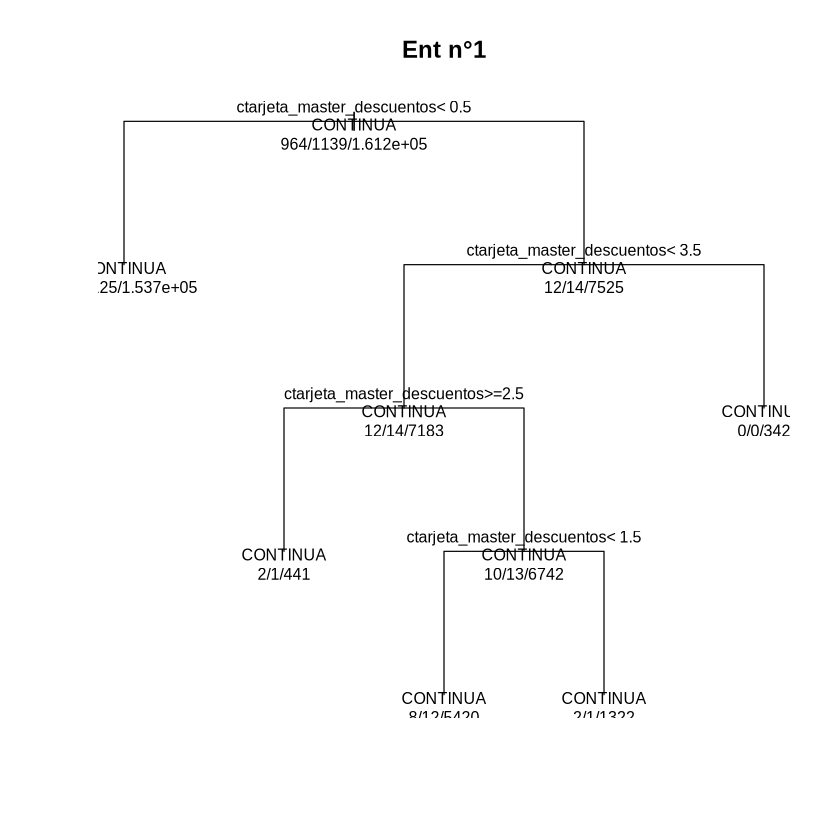

Warning message:
“Using formula(x) is deprecated when x is a character vector of length > 1.
  Consider formula(paste(x, collapse = " ")) instead.”


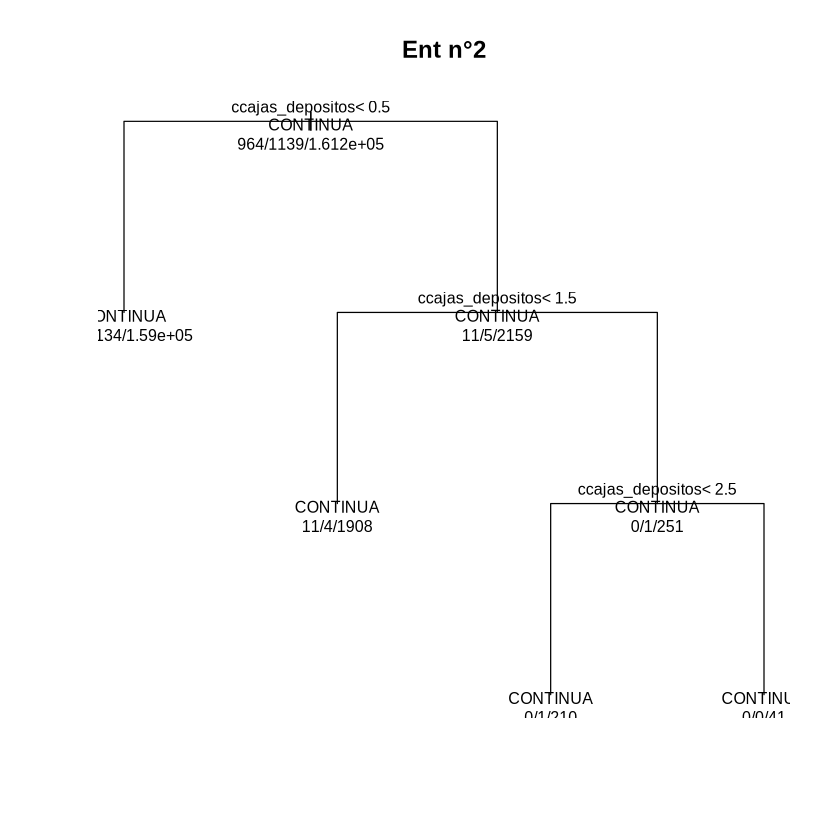

Warning message:
“Using formula(x) is deprecated when x is a character vector of length > 1.
  Consider formula(paste(x, collapse = " ")) instead.”


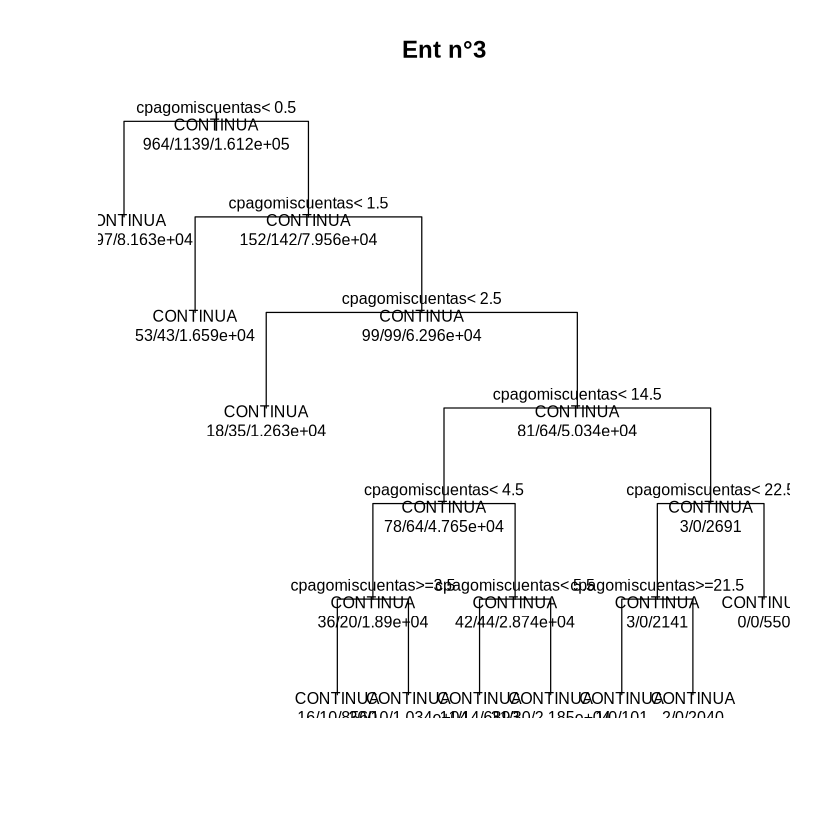

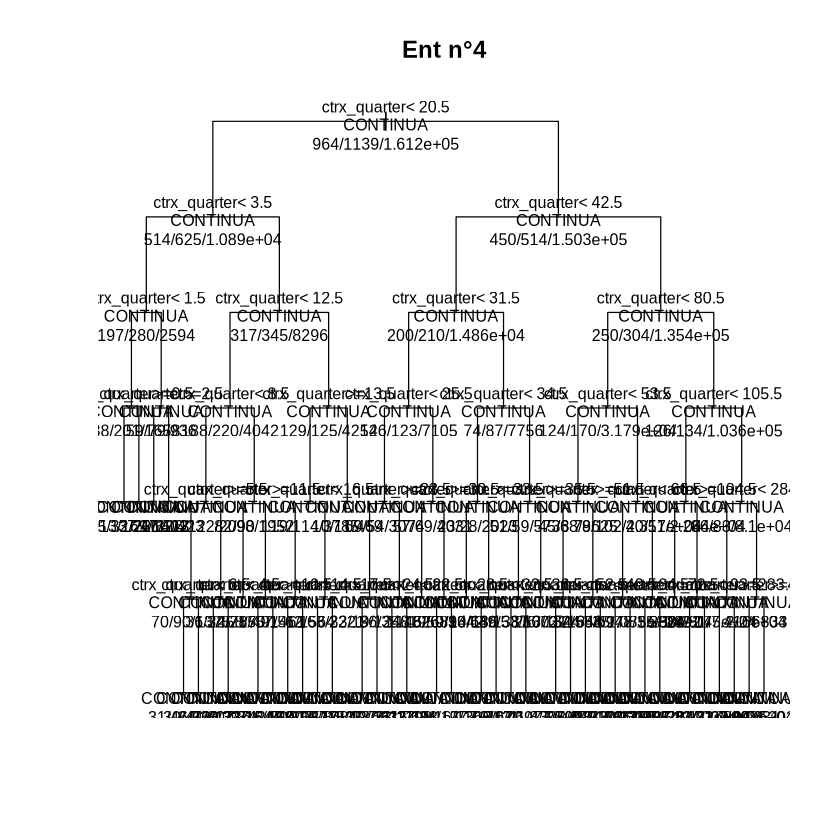

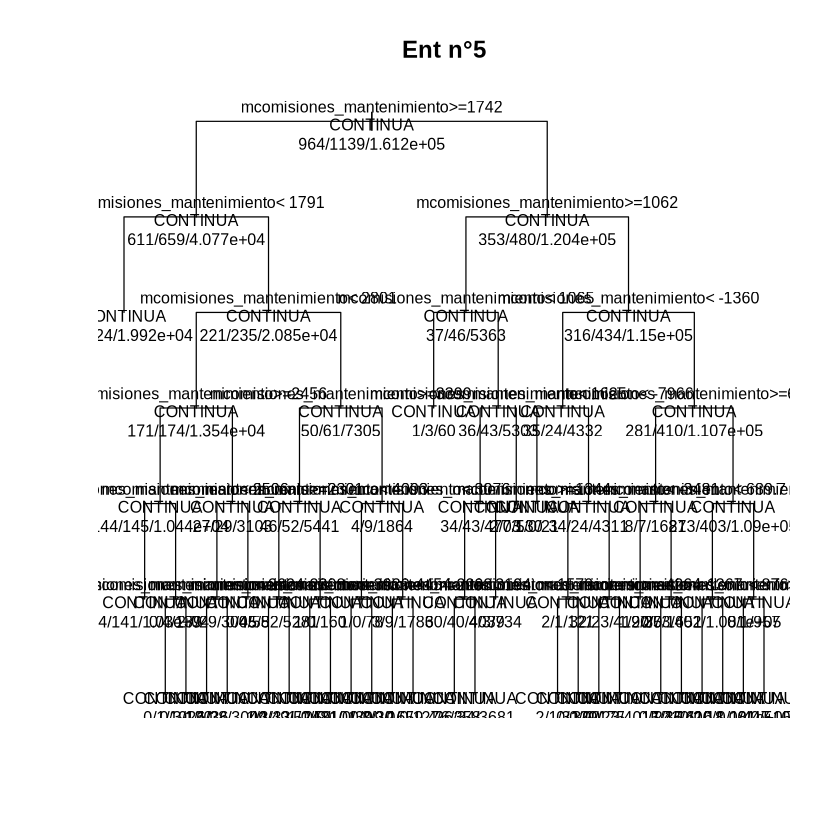

In [43]:
# vean qué diversas las formas de nuestros ents!
for (n in 1:5) {
  qty_campos_a_utilizar <- as.integer(length(campos_buenos)
    * PARAM$feature_fraction)

  # elijo los campos al azar
  campos_random <- sample(campos_buenos, qty_campos_a_utilizar)

  # armo la formula para rpart
  formulita <- paste0("clase_ternaria ~ ", campos_random)

  # genero el arbol de decision
  modelo <- rpart(formulita,
    data= dtrain,
    xval= 0,
    control= PARAM$rpart
  )


# Plot structure and add text labels
plot(modelo, uniform = TRUE, main = paste0("Ent n°",n))
text(modelo, use.n = TRUE, all = TRUE, cex = 0.8)

}

In [45]:
# que tamanos de ensemble grabo a disco
grabar <- c(1, 2, 4, 8, 16, 32, 64, 128, 256, 384, 512)

In [46]:
tb_prediccion <- dfuture[, list(numero_de_cliente, foto_mes)]
# aqui se va acumulando la probabilidad del ensemble
tb_prediccion[, prob_acumulada := 0]

set.seed(PARAM$semilla_primigenia,"L'Ecuyer-CMRG" ) # Establezco la semilla aleatoria

for (arbolito in seq(PARAM$num_trees_max) ) {

  qty_campos_a_utilizar <- as.integer(length(campos_buenos)
    * PARAM$feature_fraction)

  # elijo los campos al azar
  campos_random <- sample(campos_buenos, qty_campos_a_utilizar)

  # paso de un vector a un string con los elementos
  # separados por un signo de "+"
  # este hace falta para la formula
  campos_random <- paste(campos_random, collapse= " + ")

  # armo la formula para rpart
  formulita <- paste0("clase_ternaria ~ ", campos_random)

  # genero el arbol de decision
  modelo <- rpart(formulita,
    data= dtrain,
    xval= 0,
    control= PARAM$rpart
  )

  # aplico el modelo a los datos que no tienen clase
  prediccion <- predict(modelo, dfuture, type= "prob")

  tb_prediccion[, prob_acumulada := prob_acumulada + prediccion[, "BAJA+2"]]

  if( arbolito %in% grabar ) {
    umbral_corte <-  arbolito * (1/40)
    tb_prediccion[, Predicted := as.numeric(prob_acumulada > umbral_corte)]
    res <- realidad_evaluar( drealidad, tb_prediccion)

    cat("'\n",
      "arbolitos=", arbolito,
      " TOTAL=", res$total,
      " Public=", res$public,
      " Private=", res$private,
      "\n",
      sep= ""
    )
  } else {
    cat( arbolito, " ")
  }

  flush.console()
}


'
arbolitos=1 TOTAL=297825000 Public=289941667 Private=301203571
'
arbolitos=2 TOTAL=290950000 Public=276375000 Private=297196429
3  '
arbolitos=4 TOTAL=330935000 Public=342925000 Private=325796429
5  6  7  '
arbolitos=8 TOTAL=308770000 Public=337608333 Private=296410714
9  10  11  12  13  14  15  '
arbolitos=16 TOTAL=343970000 Public=358508333 Private=337739286
17  18  19  20  21  22  23  24  25  26  27  28  29  30  31  '
arbolitos=32 TOTAL=369930000 Public=386100000 Private=3.63e+08
33  34  35  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54  55  56  57  58  59  60  61  62  63  '
arbolitos=64 TOTAL=382800000 Public=407733333 Private=372114286
65  66  67  68  69  70  71  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90  91  92  93  94  95  96  97  98  99  100  101  102  103  104  105  106  107  108  109  110  111  112  113  114  115  116  117  118  119  120  121  122  123  124  125  126  127  '
arbolitos=128 TOTAL=383075000 Public=3

A medida que corre el loop anterior, cargar para cantidad de arbolitos reportados los resultados de la ganancia TOTAL en la hoja  **C4-Arboles Azarosos** de la planilla colaborativa



Usted NO reportará la ganancia del Public ni tampoco la del Private, por ahora es simplemente para que perciba la variabilidad existente y comience a tener plena conciencia de los fenómenos que observó en la asignatura  Data Mining del cuatrimestre anterior.

In [47]:
format(Sys.time(), "%a %b %d %X %Y")

[1] "Mon Sep 07 10:15:11 2026"



---

